In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import corner
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from jax import jacfwd, jacrev
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import corner
import os
import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import MCMC, NUTS
import multiprocessing

# Enable multi-threading (Set to number of CPU cores)
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

# ✅ Enable JAX to use multiple CPU threads
jax.config.update("jax_platform_name", "cpu")  # Force CPU usage
jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision for better accuracy

# ✅ Set NumPyro to use all CPU cores
num_cpus = multiprocessing.cpu_count()
numpyro.set_host_device_count(num_cpus)  # Use all available CPU cores

# ✅ Check CPU device count
print("JAX Devices:", jax.devices())  # Should show multiple CPU devices


JAX Devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


In [2]:
file_path = "dataverse_files/1-Fragment_C_Hole_Measurements.csv"

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)

   Section ID  Hole  Inter-hole Distance   Mean(X)   Mean(Y)
0           0     1                  NaN  15.59931  92.59653
1           1     2                  NaN  16.44167  91.50069
2           1     3             1.440694  17.30764  90.34931
3           1     4             1.456973  18.15278  89.16250
4           1     5             1.299821  18.96528  88.14792
(81, 5)


In [3]:
# Extract relevant columns
x = df['Mean(X)']
y = df['Mean(Y)']
sections = df['Section ID'].astype(str)  # Convert to string for categorical mapping

# Define distinct colors for each section
unique_sections = sections.unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_sections)))  # Use tab10 colormap

# Compute the median position for each section
section_medians = {
    sec: (np.median(x[df['Section ID'].astype(str) == sec]), np.median(y[df['Section ID'].astype(str) == sec]))
    for sec in unique_sections
}

# Sort sections by X position to prevent label overlap in clusters
sorted_sections = sorted(section_medians.keys(), key=lambda sec: section_medians[sec][0])

# Initialize label positions
base_offset = 5  # Default offset above median
min_spacing = 6  # Minimum spacing between stacked labels
label_positions = {}

# Sections to place **below** their median instead of above
below_sections = {'5'}

# Sections to be closer to the data line
closer_sections = {'4', '6'}

# Sections to move **up** manually
move_up_sections = {'1', '2', '7'}

for i, sec in enumerate(sorted_sections):
    x_mid, y_mid = section_medians[sec]

    # Adjust label position:
    if sec in below_sections:
        y_label = y_mid - (base_offset + 3)  
    elif sec in closer_sections:
        y_label = y_mid + (base_offset - 2)  
    elif sec in move_up_sections:
        y_label = y_mid + (base_offset + 5)  
    else:
        y_label = y_mid + base_offset  # Default above placement

    # Check for overlap and stack if needed (only for sections placed above)
    if sec not in below_sections:
        for prev_sec in sorted_sections[:i]:
            _, prev_y_label = label_positions[prev_sec]
            if abs(prev_y_label - y_label) < min_spacing:
                y_label = prev_y_label + min_spacing  # Stack above

    # Store the final label position
    label_positions[sec] = (x_mid, y_label)

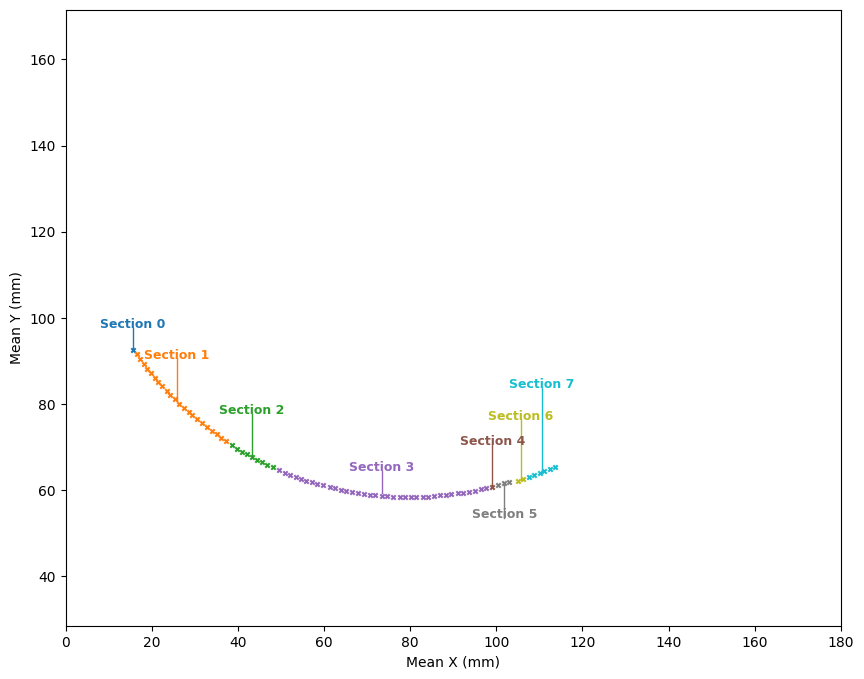

In [4]:
# Create the figure
plt.figure(figsize=(10, 8))

# Plot each section separately with a distinct color
for sec, color in zip(unique_sections, colors):
    mask = df['Section ID'].astype(str) == sec
    plt.scatter(x[mask], y[mask], label=f"Section {sec}", color=color, marker='x', s=10)
    plt.errorbar(x[mask], y[mask], xerr=0.05, yerr=0.05, fmt='none', ecolor=color, alpha=0.5)

    # Get median point and adjusted label position
    x_mid, y_mid = section_medians[sec]
    x_label, y_label = label_positions[sec]

    # Place section label as close as possible without overlap
    plt.text(x_label, y_label, f'Section {sec}', fontsize=9, fontweight='bold', color=color, ha='center',
             bbox=dict(facecolor='white', alpha=0, edgecolor='white'))

    # Add straight line from label to median point
    plt.plot([x_mid, x_mid], [y_mid, y_label], color=color, linewidth=1.0, linestyle='-')

# Labels and title
plt.xlabel('Mean X (mm)')
plt.ylabel('Mean Y (mm)')
plt.xlim(0,180)
plt.ylim(0,200)

# Equal aspect ratio for spatial accuracy
plt.gca().set_aspect('equal', adjustable='datalim')

# Show the plot
plt.show()


In [5]:
from scipy.optimize import least_squares

def circle_residuals(params, x_data, y_data):
    """
    Computes residuals for least squares circle fitting.
    Residuals are the differences between observed distances and the estimated radius.

    Parameters:
        params: [x_center, y_center, radius]
        x_data, y_data: Observed hole positions

    Returns:
        Residuals (differences between expected and observed distances)
    """
    x_center, y_center, r = params
    distances = np.sqrt((x_data - x_center) ** 2 + (y_data - y_center) ** 2)
    return distances - r  # Residuals should be close to 0 if circle fits well

# 🔍 Fit a circle to observed data
x0_guess, y0_guess = np.mean(x), np.mean(y)  # Start at data mean
r_guess = np.mean(np.sqrt((x - x0_guess) ** 2 + (y - y0_guess) ** 2))  # Estimate radius

circle_fit = least_squares(circle_residuals, [x0_guess, y0_guess, r_guess], args=(x, y))
x_center_fit, y_center_fit, r_fit = circle_fit.x

print(f"Estimated Center: ({x_center_fit:.2f}, {y_center_fit:.2f})")
print(f"Estimated Radius: {r_fit:.2f} mm")


Estimated Center: (80.47, 136.75)
Estimated Radius: 78.43 mm


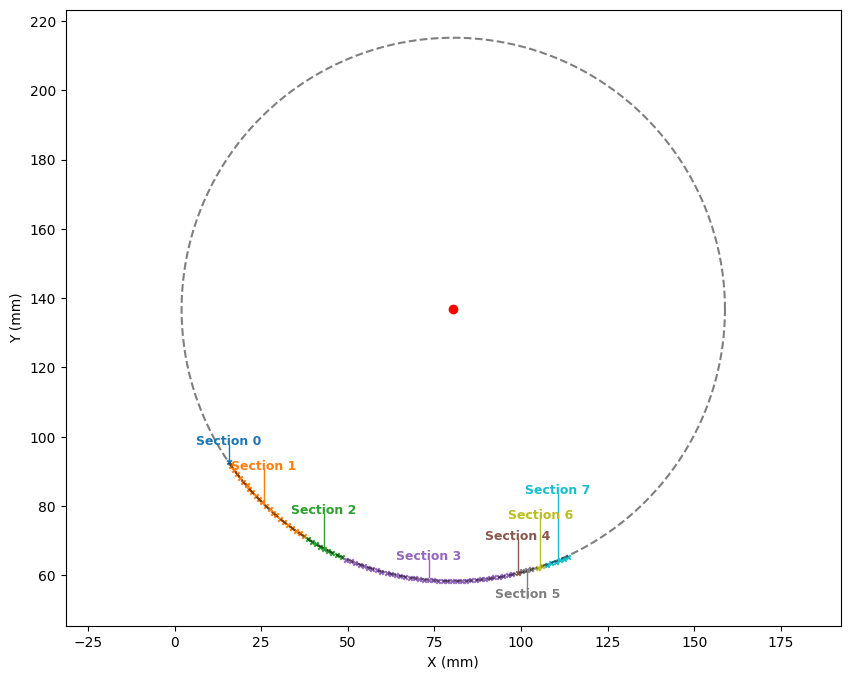

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate full circle points for visualization
theta = np.linspace(0, 2 * np.pi, 365)  # Assuming full circle had 365 points
x_full_fit = x_center_fit + r_fit * np.cos(theta)
y_full_fit = y_center_fit + r_fit * np.sin(theta)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot estimated full circle
ax.plot(x_full_fit, y_full_fit, "k", linestyle="dashed", alpha=0.5, label="Estimated Full Circle")

# Plot estimated circle center
ax.plot(x_center_fit, y_center_fit, "o", label="Estimated Center", color="red")

# Plot each section separately with distinct colors
for sec, color in zip(unique_sections, colors):
    mask = df['Section ID'].astype(str) == sec
    ax.scatter(x[mask], y[mask], label=f"Section {sec}", color=color, marker='x', s=10)
    ax.errorbar(x[mask], y[mask], xerr=0.05, yerr=0.05, fmt='none', ecolor=color, alpha=0.5)

    # Get median point and adjusted label position
    x_mid, y_mid = section_medians[sec]
    x_label, y_label = label_positions[sec]

    # Place section label as close as possible without overlap
    ax.text(x_label, y_label, f'Section {sec}', fontsize=9, fontweight='bold', color=color, ha='center',
            bbox=dict(facecolor='white', alpha=0, edgecolor='white'))

    # Add straight line from label to median point
    ax.plot([x_mid, x_mid], [y_mid, y_label], color=color, linewidth=1.0, linestyle='-')

# Labels and formatting
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")

ax.set_aspect('equal', adjustable='datalim')

# Show the plot
plt.show()


In [7]:
import numpy as np

def model(R, phis, xcent, ycent):
    """
    Computes the expected (x, y) positions of holes in the model ring.
    """
    xi = R * np.cos(phis) + xcent
    yi = R * np.sin(phis) + ycent
    return xi, yi


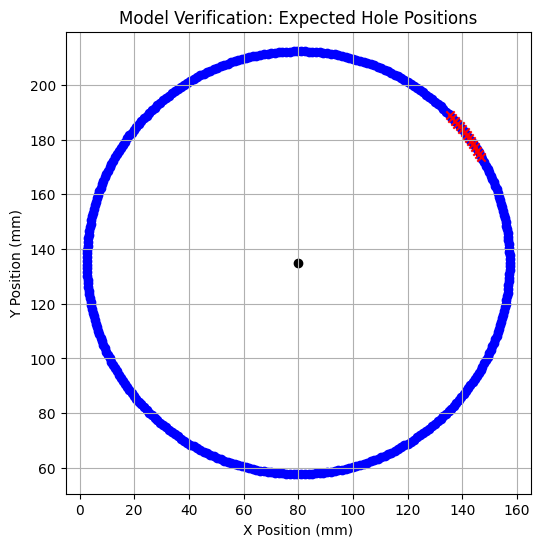

First full-ring hole position: (157.300, 135.000)
First partial-section hole position: (146.944, 173.650)
Expected center: (80, 135)


In [8]:
# Define test parameters
R_test = 77.3  # Example ring radius
N_test = 355  # Example number of holes in full ring
xcent_test = 80  # Example x-center coordinate
ycent_test = 135  # Example y-center coordinate

# Generate hole positions for a full ring
phis_full = np.linspace(0, 2 * np.pi, N_test, endpoint=False)  # Evenly spaced angles
xi_full, yi_full = model(R_test, phis_full, xcent_test, ycent_test)

# Generate hole positions for a partial ring (mimicking a fragmented section)
N_partial = 15  # Number of holes in this section
phis_partial = (2 * np.pi * np.arange(N_partial) / N_test) + np.pi / 6  # Shifted section
xi_partial, yi_partial = model(R_test, phis_partial, xcent_test, ycent_test)


# Visualization

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(xi_full, yi_full, c='blue', label="Full Ring (Expected)")

ax.scatter(xi_partial, yi_partial, c='red', label="Fragmented Section", marker='x')

ax.scatter(xcent_test, ycent_test, color='black', marker='o', label="Ring Center")

ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_title("Model Verification: Expected Hole Positions")

ax.axis('equal')  # Ensures equal scaling for accurate visualization
plt.grid(True)
plt.show()

# **Numerical Check**
print(f"First full-ring hole position: ({xi_full[0]:.3f}, {yi_full[0]:.3f})")
print(f"First partial-section hole position: ({xi_partial[0]:.3f}, {yi_partial[0]:.3f})")
print(f"Expected center: ({xcent_test}, {ycent_test})")


Log-likelihood (Isotropic Model): -51.1654
Log-likelihood (Anisotropic Model): 44.2332


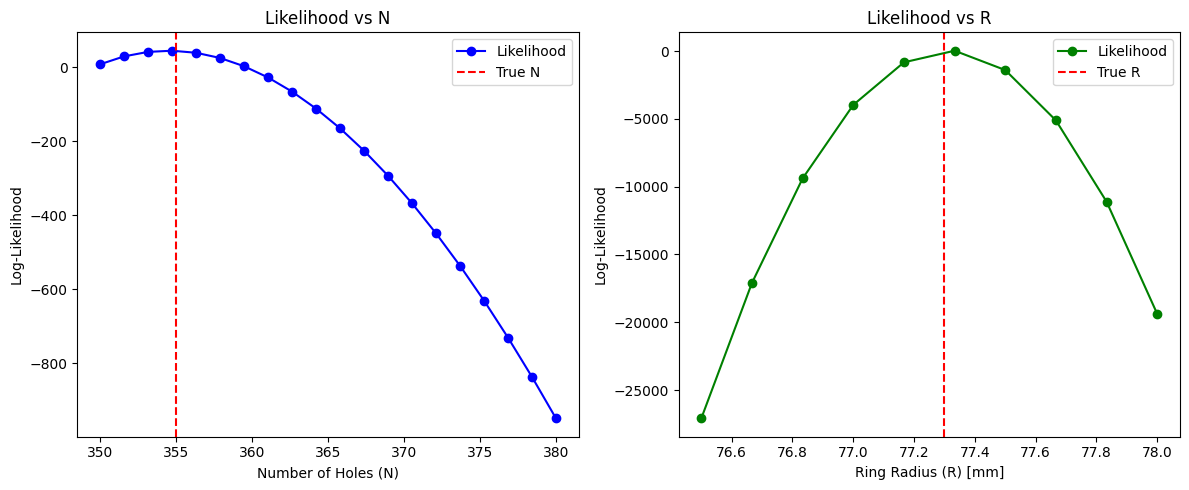

In [16]:
import jax.numpy as jnp

def log_likelihood_jax(params, data, use_anisotropic):
    """
    Computes the log-likelihood for the Antikythera Mechanism hole placement model using JAX.
    
    Implements a 2D Gaussian likelihood:
      - If `use_anisotropic` is True, uses different errors in radial (σ_r) and tangential (σ_t).
      - Otherwise, uses an isotropic Gaussian (σ) with equal error in x and y.

    Parameters:
    - params: Model parameters [N, R, sigma_r, sigma_t (or sigma), phases, xcents, ycents]
    - data: List of section-wise hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to switch between isotropic and anisotropic likelihoods.

    Returns:
    - Log-likelihood value.
    """

    # Extract primary parameters
    N, R = params[:2]
    
    if use_anisotropic:
        sigma_r, sigma_t = params[2:4]
    else:
        sigma_iso = params[2]
        sigma_r, sigma_t = sigma_iso, sigma_iso  # Isotropic case

    params_remaining = jnp.asarray(params[4:])
    assert len(params_remaining) % 3 == 0, f"Expected params[4:] length to be multiple of 3, got {len(params_remaining)}"
    phases, xcents, ycents = jnp.split(params_remaining, 3)

    logL = 0  # Log-likelihood accumulator

    # Iterate over each section of the ring
    for j, sect in enumerate(data):
        x, y = sect
        num_holes = len(x)

        # Correct Angular Positions
        phi = (2 * jnp.pi * (jnp.arange(1, num_holes + 1) - 1) / N) + phases[j]

        # Compute expected model positions
        x_model = R * jnp.cos(phi) + xcents[j]
        y_model = R * jnp.sin(phi) + ycents[j]

        # Compute error vectors in cartesian coordinates
        error_x = x - x_model
        error_y = y - y_model

        ### --- Isotropic Model --- ###
        if not use_anisotropic:
            sigma_val = sigma_r  # In isotropic case, sigma_r == sigma_t == sigma_val
            log_likelihoods_variable = (-0.5 * (error_x**2 + error_y**2) / sigma_val**2)
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_val**2)

        ### --- Anisotropic Model --- ###
        else:
            # Translate error vectors to radial and tangential coordinates
            unit_r = jnp.stack([jnp.cos(phi), jnp.sin(phi)], axis=1)
            unit_t = jnp.stack([jnp.sin(phi), -jnp.cos(phi)], axis=1)

            # List of radial and tangential error values for each hole
            error_r = error_x * unit_r[:, 0] + error_y * unit_r[:, 1]
            error_t = error_x * unit_t[:, 0] + error_y * unit_t[:, 1]

            # Compute anisotropic Gaussian likelihood for each hole
            log_likelihoods_variable = (-0.5 * ((error_r**2 / sigma_r**2) + (error_t**2 / sigma_t**2)))
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_r * sigma_t)

        # Accumulate log-likelihood
        logL += jnp.sum(log_likelihoods_variable) - log_likelihoods_constant

    return logL

def generate_synthetic_data(N_true, R_true, sigma_r, sigma_t, n_sections=6):
    """
    Generates synthetic hole position data for a fragmented ring.
    
    - `N_true`: True number of holes in full ring
    - `R_true`: True radius of the ring
    - `sigma_r, sigma_t`: Radial and tangential noise (for anisotropic model)
    - `n_sections`: Number of broken sections

    Returns:
    - data_sections: List of (x, y) coordinates for each section.
    - true_params: True parameter set used for generation.
    """

    np.random.seed(42)  # For reproducibility
    sections = []
    phases_true = np.random.uniform(0, 2 * np.pi, n_sections)  # Random section offsets
    xcents_true = np.random.uniform(70, 90, n_sections)  # Random section centers (x)
    ycents_true = np.random.uniform(130, 140, n_sections)  # Random section centers (y)

    for j in range(n_sections):
        num_holes = np.random.randint(10, 15)  # Random number of holes per section
        phis = (2 * np.pi * (np.arange(1, num_holes + 1) - 1) / N_true) + phases_true[j]

        # Compute hole positions
        x = R_true * np.cos(phis) + xcents_true[j] + np.random.normal(0, sigma_r, num_holes)
        y = R_true * np.sin(phis) + ycents_true[j] + np.random.normal(0, sigma_t, num_holes)
        
        sections.append((x, y))

    true_params = np.concatenate(([N_true, R_true, sigma_r, sigma_t], phases_true, xcents_true, ycents_true))
    return sections, true_params

# Generate synthetic data
N_true = 355
R_true = 77.3
sigma_r_true = 0.03
sigma_t_true = 0.12
data_sections, true_params = generate_synthetic_data(N_true, R_true, sigma_r_true, sigma_t_true)

# Compute true log-likelihood
logL_iso = log_likelihood_jax(true_params, data_sections, use_anisotropic=False)
logL_aniso = log_likelihood_jax(true_params, data_sections, use_anisotropic=True)

print(f"Log-likelihood (Isotropic Model): {logL_iso:.4f}")
print(f"Log-likelihood (Anisotropic Model): {logL_aniso:.4f}")

# ------------------------------
# Verify Likelihood Behavior
# ------------------------------
# Test likelihood for different values of N and R

N_test_values = np.linspace(350, 380, 20)  # Range of N values
R_test_values = np.linspace(76.5, 78, 10)  # Range of R values

log_likelihood_N = []
log_likelihood_R = []

# Compute log-likelihood for different N values
for N_test in N_test_values:
    test_params = np.copy(true_params)
    test_params[0] = N_test  # Modify N
    log_likelihood_N.append(log_likelihood_jax(test_params, data_sections, use_anisotropic=True))

# Compute log-likelihood for different R values
for R_test in R_test_values:
    test_params = np.copy(true_params)
    test_params[1] = R_test  # Modify R
    log_likelihood_R.append(log_likelihood_jax(test_params, data_sections, use_anisotropic=True))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Likelihood vs N
axes[0].plot(N_test_values, log_likelihood_N, "bo-", label="Likelihood")
axes[0].axvline(N_true, color="r", linestyle="--", label="True N")
axes[0].set_xlabel("Number of Holes (N)")
axes[0].set_ylabel("Log-Likelihood")
axes[0].set_title("Likelihood vs N")
axes[0].legend()

# Plot Likelihood vs R
axes[1].plot(R_test_values, log_likelihood_R, "go-", label="Likelihood")
axes[1].axvline(R_true, color="r", linestyle="--", label="True R")
axes[1].set_xlabel("Ring Radius (R) [mm]")
axes[1].set_ylabel("Log-Likelihood")
axes[1].set_title("Likelihood vs R")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
import jax
import jax.numpy as jnp
from jax import grad, hessian
import numpy as np

def finite_difference_grad(func, params, data, use_anisotropic=True, epsilon=1e-5):
    """
    Computes the gradient using finite differences (NumPy version).
    
    Parameters:
    - func: Function whose gradient is being computed.
    - params: NumPy array of parameters.
    - data: Input data for function evaluation.
    - use_anisotropic: Boolean flag for switching between isotropic and anisotropic models.
    - epsilon: Small perturbation for finite difference approximation.
    
    Returns:
    - grad_fd: NumPy array of finite difference gradient values.
    """

    num_params = len(params)
    grad_fd = np.zeros(num_params, dtype=np.float64)  # Ensure double precision

    for i in range(num_params):
        params_plus = np.array(params, dtype=np.float64)  # Copy parameters
        params_minus = np.array(params, dtype=np.float64)

        params_plus[i] += epsilon  # Perturb positive
        params_minus[i] -= epsilon  # Perturb negative
        
        f_plus = func(params_plus, data, use_anisotropic)
        f_minus = func(params_minus, data, use_anisotropic)

        grad_fd[i] = (f_plus - f_minus) / (2 * epsilon)  # Central difference

    return grad_fd

# Ensure `data` is structured as a list of (x, y) tuples grouped by section
data_list = []
grouped = df.groupby("Section ID")

for section_id, group in grouped:
    x_values = group["Mean(X)"].values
    y_values = group["Mean(Y)"].values
    data_list.append((x_values, y_values))  # Append (x, y) as tuple

# Define the JAX autodiff gradient function
grad_jax = grad(log_likelihood_jax)
hess_jax = hessian(log_likelihood_jax)

# Example parameter vector
params = jnp.array([355, 77.3, 0.03, 0.12] + [0] * 24)  # Example parameters

# Compute gradients
grad_autodiff = grad_jax(params, data_list, use_anisotropic=True)
grad_fd = finite_difference_grad(log_likelihood_jax, params, data_list, use_anisotropic=True)

# Print comparison
print("\n🔹 JAX Autodiff Gradient:\n", grad_autodiff)
print("\n🔹 Finite Difference Gradient:\n", grad_fd)

# Compute absolute differences
grad_diff = jnp.abs(grad_autodiff - grad_fd)
print("\n🔹 Gradient Differences:\n", grad_diff)

# Compute relative differences
relative_diff = grad_diff / (jnp.abs(grad_autodiff) + 1e-8)  # Adding a small value to avoid division by zero
print("\n🔹 Relative Differences:\n", relative_diff)


🔹 JAX Autodiff Gradient:
 [-3.08296810e+04 -5.17280493e+05  2.80567149e+09  1.52944054e+08
  6.44838602e+06  7.56738666e+07  2.10957508e+07  1.23092824e+07
 -1.05294285e+06 -3.79327248e+06 -3.03211357e+06 -1.13177049e+07
 -6.85563222e+04 -9.23644828e+05 -2.96742523e+05  2.69047350e+05
  2.42260778e+04  8.48866621e+04  6.40646228e+04  2.38474678e+05
  6.43031458e+03 -2.28132897e+04  2.18835268e+04  3.27690466e+05
  4.21595278e+03  1.40260784e+04  9.11890444e+03  3.59779192e+04]

🔹 Finite Difference Gradient:
 [-3.08296811e+04 -5.17280493e+05  2.80567211e+09  1.52944056e+08
  6.44838602e+06  7.56738666e+07  2.10957508e+07  1.23092824e+07
 -1.05294285e+06 -3.79327248e+06 -3.03211357e+06 -1.13177049e+07
 -6.85563222e+04 -9.23644828e+05 -2.96742523e+05  2.69047350e+05
  2.42260776e+04  8.48866623e+04  6.40646227e+04  2.38474678e+05
  6.43031448e+03 -2.28132896e+04  2.18835264e+04  3.27690466e+05
  4.21595275e+03  1.40260782e+04  9.11890455e+03  3.59779190e+04]

🔹 Gradient Differences:
 [4.

In [19]:
# Compute forward-mode Jacobian (alternative way to compute derivatives)
jac_fwd = jacfwd(log_likelihood_jax)(params, data_list, use_anisotropic=True)

# Compute reverse-mode Jacobian (should match forward-mode)
jac_rev = jacrev(log_likelihood_jax)(params, data_list, use_anisotropic=True)

# Compare against the original analytic gradient
print(f"Forward-Mode Gradient: {jac_fwd}")
print(f"Reverse-Mode Gradient: {jac_rev}")


Forward-Mode Gradient: [-3.08296810e+04 -5.17280493e+05  2.80567149e+09  1.52944054e+08
  6.44838602e+06  7.56738666e+07  2.10957508e+07  1.23092824e+07
 -1.05294285e+06 -3.79327248e+06 -3.03211357e+06 -1.13177049e+07
 -6.85563222e+04 -9.23644828e+05 -2.96742523e+05  2.69047350e+05
  2.42260778e+04  8.48866621e+04  6.40646228e+04  2.38474678e+05
  6.43031458e+03 -2.28132897e+04  2.18835268e+04  3.27690466e+05
  4.21595278e+03  1.40260784e+04  9.11890444e+03  3.59779192e+04]
Reverse-Mode Gradient: [-3.08296810e+04 -5.17280493e+05  2.80567149e+09  1.52944054e+08
  6.44838602e+06  7.56738666e+07  2.10957508e+07  1.23092824e+07
 -1.05294285e+06 -3.79327248e+06 -3.03211357e+06 -1.13177049e+07
 -6.85563222e+04 -9.23644828e+05 -2.96742523e+05  2.69047350e+05
  2.42260778e+04  8.48866621e+04  6.40646228e+04  2.38474678e+05
  6.43031458e+03 -2.28132897e+04  2.18835268e+04  3.27690466e+05
  4.21595278e+03  1.40260784e+04  9.11890444e+03  3.59779192e+04]


In [20]:
import pandas as pd
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
import numpy as np

# Load and preprocess the data
file_path = "dataverse_files/1-Fragment_C_Hole_Measurements.csv"
df = pd.read_csv(file_path)
df = df.sort_values(by=["Section ID", "Hole"])  # Sort by section and hole index

# Remove Sections 0 and 4
valid_sections = [1, 2, 3, 5, 6, 7]  # Keep only these sections
df_filtered = df[df["Section ID"].isin(valid_sections)]

# Group by Section ID
data_list = []
grouped = df_filtered.groupby("Section ID")

for section_id, group in grouped:
    x_values = group["Mean(X)"].values
    y_values = group["Mean(Y)"].values
    data_list.append((x_values, y_values))  # Append (x, y) tuple for this section

# Sanity Check
total_holes = sum(len(sect[0]) for sect in data_list)
assert total_holes == 79, f"Expected 79 holes, but got {total_holes}"

print("Data formatted correctly with 6 sections and 79 holes.")

# Compute gradient of log-likelihood using JAX
grad_log_likelihood = jax.grad(log_likelihood_jax)

def neg_log_likelihood(params, data, use_anisotropic=True):
    """ Convert log-likelihood into a minimization problem (negative log-likelihood). """
    return -log_likelihood_jax(params, data, use_anisotropic)

def neg_grad_log_likelihood(params, data, use_anisotropic=True):
    """ Compute gradient of negative log-likelihood for optimization. """
    return -grad_log_likelihood(params, data, use_anisotropic)

# Define Constraints
bounds = [
    (340, 370),  # N: Number of holes (continuous for optimization)
    (50, 150),   # R: Ring radius
    (1e-3, 2),   # σr: Radial uncertainty (positive)
    (1e-3, 2)    # σt: Tangential uncertainty (positive)
] + [(None, None)] * 18  # Phases, x offsets, y offsets (unbounded)

# Initial Parameter Guess
np.random.seed(42)  # Fix randomness for reproducibility

# Median values
N_median = 355.24
R_median = 77.34
σr_median = 0.028
σt_median = 0.129

x_offsets_median = np.array([79.69, 79.91, 79.86, 81.44, 81.56, 83.22])
y_offsets_median = np.array([136.03, 135.71, 135.71, 136.10, 135.85, 136.42])
α_median_degrees = np.array([-145.72, -145.67, -145.54, -146.71, -146.36, -147.80])
α_median = np.radians(α_median_degrees)  # Convert to radians

# Add small noise to avoid poor local minima
N_init = N_median + np.random.uniform(-1.5, 1.5)
R_init = R_median + np.random.uniform(-0.3, 0.3)
σr_init = σr_median + np.random.uniform(-0.003, 0.003)
σt_init = σt_median + np.random.uniform(-0.012, 0.012)

x_offsets_init = x_offsets_median + np.random.uniform(-0.5, 0.5, size=len(x_offsets_median))
y_offsets_init = y_offsets_median + np.random.uniform(-0.5, 0.5, size=len(y_offsets_median))
α_init = α_median + np.random.uniform(-0.05, 0.05, size=len(α_median))  # Small perturbation

# Convert to JAX array for optimization
initial_params = jnp.array(
    [N_init, R_init, σr_init, σt_init] + list(α_init) + list(x_offsets_init) + list(y_offsets_init)
)

Data formatted correctly with 6 sections and 79 holes.


In [21]:
# Run Optimization
result = minimize(
    neg_log_likelihood,  # Function to minimize (-log likelihood)
    initial_params,  # Initial parameter values
    args=(data_list, True),  # Pass formatted data
    method="L-BFGS-B",
    jac=neg_grad_log_likelihood,
    bounds=bounds
)

# Extract Results
optimal_params = result.x
optimal_log_likelihood = -result.fun  # Convert back to log-likelihood

# Print the optimized parameters and log-likelihood
print("Optimized Parameters:", optimal_params)
print("Maximized Log-Likelihood:", optimal_log_likelihood)

Optimized Parameters: [ 3.54881657e+02  7.72684445e+01  2.57800429e-02  1.22591967e-01
 -2.52582135e+00 -2.13563016e+00 -1.97446948e+00 -1.32515376e+00
 -1.26338644e+00 -1.25299066e+00  7.96418660e+01  7.98680118e+01
  7.98540144e+01  8.16606680e+01  8.15887362e+01  8.32308316e+01
  1.35981307e+02  1.35658721e+02  1.35637581e+02  1.36091630e+02
  1.35794112e+02  1.36351010e+02]
Maximized Log-Likelihood: 230.6145905045154


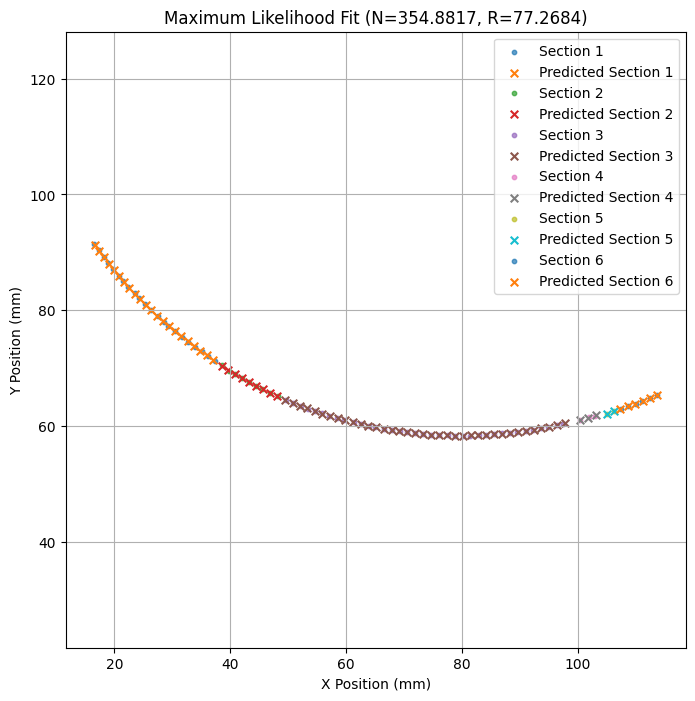

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mle_results(optimal_params, data_list, use_anisotropic=True):
    """
    Plots the measured hole positions and the maximum likelihood estimated model positions.
    
    Parameters:
    - optimal_params: The estimated parameters from MLE optimization.
    - data_list: The filtered dataset containing (x, y) coordinates grouped by section.
    - use_anisotropic: Boolean flag indicating whether anisotropic uncertainties were used.
    """

    # Extract optimized parameters
    N_opt, R_opt = optimal_params[:2]
    sigma_r_opt, sigma_t_opt = optimal_params[2:4]
    phases_opt, xcents_opt, ycents_opt = np.split(optimal_params[4:], 3)

    # Prepare figure
    plt.figure(figsize=(8, 8))

    # Plot measured hole positions
    for i, (x, y) in enumerate(data_list):
        plt.scatter(x, y, label=f"Section {i+1}", s=10, alpha=0.7)  # Measured data

        # Compute the optimized hole positions using the best-fit parameters
        num_holes = len(x)
        phis = (2 * np.pi * (np.arange(1, num_holes + 1) - 1) / N_opt) + phases_opt[i]
        x_pred = R_opt * np.cos(phis) + xcents_opt[i]
        y_pred = R_opt * np.sin(phis) + ycents_opt[i]

        # Plot predicted hole positions
        plt.scatter(x_pred, y_pred, marker="x", label=f"Predicted Section {i+1}", s=30)

    # Formatting
    plt.xlabel("X Position (mm)")
    plt.ylabel("Y Position (mm)")
    plt.title(f"Maximum Likelihood Fit (N={N_opt:.4f}, R={R_opt:.4f})")
    plt.legend()
    plt.axis("equal")  # Maintain aspect ratio
    plt.grid()

    # Show plot
    plt.show()

# === Call the function to visualize ===
plot_mle_results(optimal_params, data_list, use_anisotropic=True)


In [25]:
import jax.numpy as jnp

def log_likelihood_jax_with_covariance(params, data, use_anisotropic):
    """
    Computes the log-likelihood for the Antikythera Mechanism hole placement model using JAX.
    Also returns the covariance matrices for inspection.
    
    Implements a 2D Gaussian likelihood:
      - If `use_anisotropic` is True, uses different errors in radial (σ_r) and tangential (σ_t).
      - Otherwise, uses an isotropic Gaussian (σ) with equal error in x and y.

    Parameters:
    - params: Model parameters [N, R, sigma_r, sigma_t (or sigma), phases, xcents, ycents]
    - data: List of section-wise hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to switch between isotropic and anisotropic likelihoods.

    Returns:
    - Log-likelihood value.
    - Covariance matrices for each section.
    """

    # Extract primary parameters
    N, R = params[:2]
    
    if use_anisotropic:
        sigma_r, sigma_t = params[2:4]
    else:
        sigma_iso = params[2]
        sigma_r, sigma_t = sigma_iso, sigma_iso  # Isotropic case

    params_remaining = jnp.asarray(params[4:])
    assert len(params_remaining) % 3 == 0, f"Expected params[4:] length to be multiple of 3, got {len(params_remaining)}"
    phases, xcents, ycents = jnp.split(params_remaining, 3)

    logL = 0  # Log-likelihood accumulator
    covariance_matrices = []  # List to store covariance matrices

    # Iterate over each section of the ring
    for j, sect in enumerate(data):
        x, y = sect
        num_holes = len(x)

        # Correct Angular Positions
        phi = (2 * jnp.pi * (jnp.arange(1, num_holes + 1) - 1) / N) + phases[j]

        # Compute expected model positions
        x_model = R * jnp.cos(phi) + xcents[j]
        y_model = R * jnp.sin(phi) + ycents[j]

        # Compute error vectors in cartesian coordinates
        error_x = x - x_model
        error_y = y - y_model

        ### --- Isotropic Model --- ###
        if not use_anisotropic:
            sigma_val = sigma_r  # In isotropic case, sigma_r == sigma_t == sigma_val
            log_likelihoods_variable = (-0.5 * (error_x**2 + error_y**2) / sigma_val**2)
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_val**2)
            covariance_matrix = jnp.array([[sigma_val**2, 0], [0, sigma_val**2]])

        ### --- Anisotropic Model --- ###
        else:
            # Translate error vectors to radial and tangential coordinates
            unit_r = jnp.stack([jnp.cos(phi), jnp.sin(phi)], axis=1)
            unit_t = jnp.stack([jnp.sin(phi), -jnp.cos(phi)], axis=1)

            # List of radial and tangential error values for each hole
            error_r = error_x * unit_r[:, 0] + error_y * unit_r[:, 1]
            error_t = error_x * unit_t[:, 0] + error_y * unit_t[:, 1]

            # Compute anisotropic Gaussian likelihood for each hole
            log_likelihoods_variable = (-0.5 * ((error_r**2 / sigma_r**2) + (error_t**2 / sigma_t**2)))
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_r * sigma_t)
            covariance_matrix = jnp.array([[sigma_r**2, 0], [0, sigma_t**2]])

        # Accumulate log-likelihood
        logL += jnp.sum(log_likelihoods_variable) - log_likelihoods_constant
        covariance_matrices.append(covariance_matrix)

    return logL, covariance_matrices

# Example usage
params = jnp.array([355, 77.3, 0.03, 0.12] + [0] * 24)  # Example parameters
logL, cov_matrices = log_likelihood_jax_with_covariance(params, data_list, use_anisotropic=True)

print("Log-Likelihood:", logL)
print("Covariance Matrices:")
for i, cov in enumerate(cov_matrices):
    print(f"Section {i+1}:\n{cov}")

Log-Likelihood: -48456717.66639065
Covariance Matrices:
Section 1:
[[0.0009 0.    ]
 [0.     0.0144]]
Section 2:
[[0.0009 0.    ]
 [0.     0.0144]]
Section 3:
[[0.0009 0.    ]
 [0.     0.0144]]
Section 4:
[[0.0009 0.    ]
 [0.     0.0144]]
Section 5:
[[0.0009 0.    ]
 [0.     0.0144]]
Section 6:
[[0.0009 0.    ]
 [0.     0.0144]]


Data formatted correctly with 6 sections and 79 holes.
Optimized Parameters: [ 3.54881657e+02  7.72684445e+01  2.57800429e-02  1.22591967e-01
 -2.52582135e+00 -2.13563016e+00 -1.97446948e+00 -1.32515376e+00
 -1.26338644e+00 -1.25299066e+00  7.96418660e+01  7.98680118e+01
  7.98540144e+01  8.16606680e+01  8.15887362e+01  8.32308316e+01
  1.35981307e+02  1.35658721e+02  1.35637581e+02  1.36091630e+02
  1.35794112e+02  1.36351010e+02]
Maximized Log-Likelihood: 230.6145905045154
Log-Likelihood: 230.6145905045154
Covariance Matrices:
Section 1:
[[0.00066461 0.        ]
 [0.         0.01502879]]
Section 2:
[[0.00066461 0.        ]
 [0.         0.01502879]]
Section 3:
[[0.00066461 0.        ]
 [0.         0.01502879]]
Section 4:
[[0.00066461 0.        ]
 [0.         0.01502879]]
Section 5:
[[0.00066461 0.        ]
 [0.         0.01502879]]
Section 6:
[[0.00066461 0.        ]
 [0.         0.01502879]]


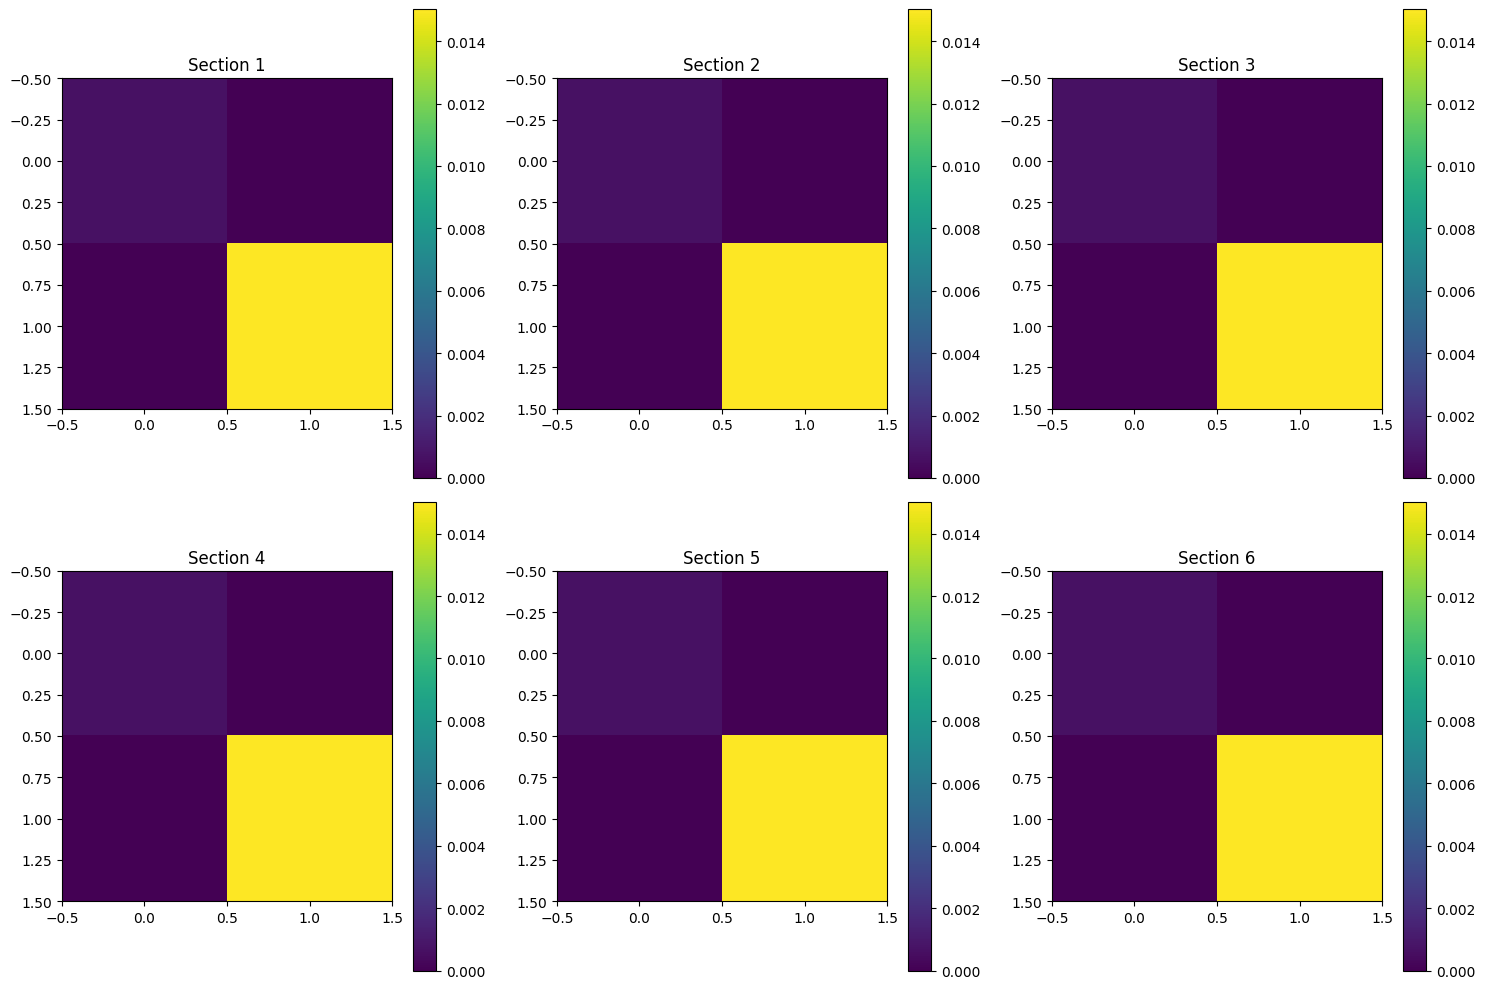

In [26]:
import pandas as pd
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

def log_likelihood_jax_with_covariance(params, data, use_anisotropic):
    """
    Computes the log-likelihood for the Antikythera Mechanism hole placement model using JAX.
    Also returns the covariance matrices for inspection.
    
    Implements a 2D Gaussian likelihood:
      - If `use_anisotropic` is True, uses different errors in radial (σ_r) and tangential (σ_t).
      - Otherwise, uses an isotropic Gaussian (σ) with equal error in x and y.

    Parameters:
    - params: Model parameters [N, R, sigma_r, sigma_t (or sigma), phases, xcents, ycents]
    - data: List of section-wise hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to switch between isotropic and anisotropic likelihoods.

    Returns:
    - Log-likelihood value.
    - Covariance matrices for each section.
    """

    # Extract primary parameters
    N, R = params[:2]
    
    if use_anisotropic:
        sigma_r, sigma_t = params[2:4]
    else:
        sigma_iso = params[2]
        sigma_r, sigma_t = sigma_iso, sigma_iso  # Isotropic case

    params_remaining = jnp.asarray(params[4:])
    assert len(params_remaining) % 3 == 0, f"Expected params[4:] length to be multiple of 3, got {len(params_remaining)}"
    phases, xcents, ycents = jnp.split(params_remaining, 3)

    logL = 0  # Log-likelihood accumulator
    covariance_matrices = []  # List to store covariance matrices

    # Iterate over each section of the ring
    for j, sect in enumerate(data):
        x, y = sect
        num_holes = len(x)

        # Correct Angular Positions
        phi = (2 * jnp.pi * (jnp.arange(1, num_holes + 1) - 1) / N) + phases[j]

        # Compute expected model positions
        x_model = R * jnp.cos(phi) + xcents[j]
        y_model = R * jnp.sin(phi) + ycents[j]

        # Compute error vectors in cartesian coordinates
        error_x = x - x_model
        error_y = y - y_model

        ### --- Isotropic Model --- ###
        if not use_anisotropic:
            sigma_val = sigma_r  # In isotropic case, sigma_r == sigma_t == sigma_val
            log_likelihoods_variable = (-0.5 * (error_x**2 + error_y**2) / sigma_val**2)
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_val**2)
            covariance_matrix = jnp.array([[sigma_val**2, 0], [0, sigma_val**2]])

        ### --- Anisotropic Model --- ###
        else:
            # Translate error vectors to radial and tangential coordinates
            unit_r = jnp.stack([jnp.cos(phi), jnp.sin(phi)], axis=1)
            unit_t = jnp.stack([jnp.sin(phi), -jnp.cos(phi)], axis=1)

            # List of radial and tangential error values for each hole
            error_r = error_x * unit_r[:, 0] + error_y * unit_r[:, 1]
            error_t = error_x * unit_t[:, 0] + error_y * unit_t[:, 1]

            # Compute anisotropic Gaussian likelihood for each hole
            log_likelihoods_variable = (-0.5 * ((error_r**2 / sigma_r**2) + (error_t**2 / sigma_t**2)))
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_r * sigma_t)
            covariance_matrix = jnp.array([[sigma_r**2, 0], [0, sigma_t**2]])

        # Accumulate log-likelihood
        logL += jnp.sum(log_likelihoods_variable) - log_likelihoods_constant
        covariance_matrices.append(covariance_matrix)

    return logL, covariance_matrices

# Load and preprocess the data
file_path = "dataverse_files/1-Fragment_C_Hole_Measurements.csv"
df = pd.read_csv(file_path)
df = df.sort_values(by=["Section ID", "Hole"])  # Sort by section and hole index

# Remove Sections 0 and 4
valid_sections = [1, 2, 3, 5, 6, 7]  # Keep only these sections
df_filtered = df[df["Section ID"].isin(valid_sections)]

# Group by Section ID
data_list = []
grouped = df_filtered.groupby("Section ID")

for section_id, group in grouped:
    x_values = group["Mean(X)"].values
    y_values = group["Mean(Y)"].values
    data_list.append((x_values, y_values))  # Append (x, y) tuple for this section

# Sanity Check
total_holes = sum(len(sect[0]) for sect in data_list)
assert total_holes == 79, f"Expected 79 holes, but got {total_holes}"

print("Data formatted correctly with 6 sections and 79 holes.")

# Compute gradient of log-likelihood using JAX
grad_log_likelihood = jax.grad(log_likelihood_jax)

def neg_log_likelihood(params, data, use_anisotropic=True):
    """ Convert log-likelihood into a minimization problem (negative log-likelihood). """
    return -log_likelihood_jax(params, data, use_anisotropic)

def neg_grad_log_likelihood(params, data, use_anisotropic=True):
    """ Compute gradient of negative log-likelihood for optimization. """
    return -grad_log_likelihood(params, data, use_anisotropic)

# Define Constraints
bounds = [
    (340, 370),  # N: Number of holes (continuous for optimization)
    (50, 150),   # R: Ring radius
    (1e-3, 2),   # σr: Radial uncertainty (positive)
    (1e-3, 2)    # σt: Tangential uncertainty (positive)
] + [(None, None)] * 18  # Phases, x offsets, y offsets (unbounded)

# Initial Parameter Guess
np.random.seed(42)  # Fix randomness for reproducibility

# Median values
N_median = 355.24
R_median = 77.34
σr_median = 0.028
σt_median = 0.129

x_offsets_median = np.array([79.69, 79.91, 79.86, 81.44, 81.56, 83.22])
y_offsets_median = np.array([136.03, 135.71, 135.71, 136.10, 135.85, 136.42])
α_median_degrees = np.array([-145.72, -145.67, -145.54, -146.71, -146.36, -147.80])
α_median = np.radians(α_median_degrees)  # Convert to radians

# Add small noise to avoid poor local minima
N_init = N_median + np.random.uniform(-1.5, 1.5)
R_init = R_median + np.random.uniform(-0.3, 0.3)
σr_init = σr_median + np.random.uniform(-0.003, 0.003)
σt_init = σt_median + np.random.uniform(-0.012, 0.012)

x_offsets_init = x_offsets_median + np.random.uniform(-0.5, 0.5, size=len(x_offsets_median))
y_offsets_init = y_offsets_median + np.random.uniform(-0.5, 0.5, size=len(y_offsets_median))
α_init = α_median + np.random.uniform(-0.05, 0.05, size=len(α_median))  # Small perturbation

# Convert to JAX array for optimization
initial_params = jnp.array(
    [N_init, R_init, σr_init, σt_init] + list(α_init) + list(x_offsets_init) + list(y_offsets_init)
)

# Run Optimization
result = minimize(
    neg_log_likelihood,  # Function to minimize (-log likelihood)
    initial_params,  # Initial parameter values
    args=(data_list, True),  # Pass formatted data
    method="L-BFGS-B",
    jac=neg_grad_log_likelihood,
    bounds=bounds
)

# Extract Results
optimal_params = result.x
optimal_log_likelihood = -result.fun  # Convert back to log-likelihood

# Print the optimized parameters and log-likelihood
print("Optimized Parameters:", optimal_params)
print("Maximized Log-Likelihood:", optimal_log_likelihood)

# Inspect Covariance Matrices
logL, cov_matrices = log_likelihood_jax_with_covariance(optimal_params, data_list, use_anisotropic=True)

print("Log-Likelihood:", logL)
print("Covariance Matrices:")
for i, cov in enumerate(cov_matrices):
    print(f"Section {i+1}:\n{cov}")

# Plot Covariance Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cov in enumerate(cov_matrices):
    im = axes[i].imshow(cov, cmap='viridis')
    axes[i].set_title(f'Section {i+1}')
    fig.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

In [29]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median
import jax

def log_likelihood_jax(params, data, use_anisotropic):
    """
    Computes the log-likelihood for the Antikythera Mechanism hole placement model using JAX.
    
    Implements a 2D Gaussian likelihood:
      - If `use_anisotropic` is True, uses different errors in radial (σ_r) and tangential (σ_t).
      - Otherwise, uses an isotropic Gaussian (σ) with equal error in x and y.

    Parameters:
    - params: Model parameters [N, R, sigma_r, sigma_t (or sigma), phases, xcents, ycents]
    - data: List of section-wise hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to switch between isotropic and anisotropic likelihoods.

    Returns:
    - Log-likelihood value.
    """
    # Extract primary parameters
    N, R = params[:2]
    
    if use_anisotropic:
        sigma_r, sigma_t = params[2:4]
    else:
        sigma_iso = params[2]
        sigma_r, sigma_t = sigma_iso, sigma_iso  # Isotropic case

    params_remaining = jnp.asarray(params[4:])
    assert len(params_remaining) % 3 == 0, f"Expected params[4:] length to be multiple of 3, got {len(params_remaining)}"
    phases, xcents, ycents = jnp.split(params_remaining, 3)

    logL = 0  # Log-likelihood accumulator

    # Iterate over each section of the ring
    for j, sect in enumerate(data):
        x, y = sect
        num_holes = len(x)

        # Correct Angular Positions
        phi = (2 * jnp.pi * (jnp.arange(1, num_holes + 1) - 1) / N) + phases[j]

        # Compute expected model positions
        x_model = R * jnp.cos(phi) + xcents[j]
        y_model = R * jnp.sin(phi) + ycents[j]

        # Compute error vectors in cartesian coordinates
        error_x = x - x_model
        error_y = y - y_model

        ### --- Isotropic Model --- ###
        if not use_anisotropic:
            sigma_val = sigma_r  # In isotropic case, sigma_r == sigma_t == sigma_val
            log_likelihoods_variable = (-0.5 * (error_x**2 + error_y**2) / sigma_val**2)
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_val**2)

        ### --- Anisotropic Model --- ###
        else:
            # Translate error vectors to radial and tangential coordinates
            unit_r = jnp.stack([jnp.cos(phi), jnp.sin(phi)], axis=1)
            unit_t = jnp.stack([jnp.sin(phi), -jnp.cos(phi)], axis=1)

            # List of radial and tangential error values for each hole
            error_r = error_x * unit_r[:, 0] + error_y * unit_r[:, 1]
            error_t = error_x * unit_t[:, 0] + error_y * unit_t[:, 1]

            # Compute anisotropic Gaussian likelihood for each hole
            log_likelihoods_variable = (-0.5 * ((error_r**2 / sigma_r**2) + (error_t**2 / sigma_t**2)))
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_r * sigma_t)

        # Accumulate log-likelihood
        logL += jnp.sum(log_likelihoods_variable) - log_likelihoods_constant

    return logL

def bayesian_hole_position_model(data, use_anisotropic=True):
    """
    Bayesian model for hole positions using NumPyro.
    
    Parameters:
    - data: List of measured hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to enable anisotropic covariance matrix.
    """

    # 🔹 **Universal Priors (Ring-level parameters)**
    N = numpyro.sample('N', dist.Normal(355, 3))  # Centered at 355, with std=3
    R = numpyro.sample('R', dist.Normal(77.3, 0.5))  # Centered at 77.3, std=0.5

    if use_anisotropic:
        sigma_r = numpyro.sample('sigma_r', dist.LogNormal(jnp.log(0.028), 0.1))  # Constrains to positive values
        sigma_t = numpyro.sample('sigma_t', dist.LogNormal(jnp.log(0.129), 0.1))
    else:
        sigma_iso = numpyro.sample('sigma', dist.LogNormal(jnp.log(0.05), 0.1))

    # 🔹 **Section-Specific Priors**
    num_sections = len(data)  # Number of fractured sections in the dataset
    phases = numpyro.sample('phases', dist.Normal(-145, 2).expand([num_sections]))  # Rotation offsets
    x_offsets = numpyro.sample('x_offsets', dist.Normal(80, 3).expand([num_sections]))  # X-offset per section
    y_offsets = numpyro.sample('y_offsets', dist.Normal(135, 3).expand([num_sections]))  # Y-offset per section

    # 🔹 **Likelihood Calculation**
    params = jnp.concatenate([
        jnp.array([N, R, sigma_r, sigma_t] if use_anisotropic else [N, R, sigma_iso]),
        phases, x_offsets, y_offsets
    ])

    logL = log_likelihood_jax(params=params, data=data, use_anisotropic=use_anisotropic)

    # 🔹 **Define Log-Likelihood in NumPyro**
    numpyro.factor("log_likelihood", logL)

# Load and preprocess the data
file_path = "dataverse_files/1-Fragment_C_Hole_Measurements.csv"
df = pd.read_csv(file_path)
df = df.sort_values(by=["Section ID", "Hole"])  # Sort by section and hole index

# Remove Sections 0 and 4
valid_sections = [1, 2, 3, 5, 6, 7]  # Keep only these sections
df_filtered = df[df["Section ID"].isin(valid_sections)]

# Group by Section ID
data_list = []
grouped = df_filtered.groupby("Section ID")

for section_id, group in grouped:
    x_values = group["Mean(X)"].values
    y_values = group["Mean(Y)"].values
    data_list.append((x_values, y_values))  # Append (x, y) tuple for this section

# Sanity Check
total_holes = sum(len(sect[0]) for sect in data_list)
assert total_holes == 79, f"Expected 79 holes, but got {total_holes}"

print("Data formatted correctly with 6 sections and 79 holes.")

# Run MCMC
num_chains = 12  # Use all 12 CPU cores
num_warmup = 8000  # Increase burn-in steps
num_samples = 10000  # Total samples per chain

nuts_kernel = NUTS(bayesian_hole_position_model, init_strategy=init_to_median)

mcmc = MCMC(nuts_kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

key = jax.random.PRNGKey(0)
mcmc.run(key, data_list, use_anisotropic=True)

# Print summary of MCMC results
mcmc.print_summary()

Data formatted correctly with 6 sections and 79 holes.


  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

...

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
           N    354.46      2.53    354.99    352.56    357.70      8.09      1.95
           R     77.20      0.44     77.28     76.80     77.82      8.91      1.73
   phases[0]   -146.77      0.88   -147.04   -147.04   -147.04      6.00     83.86
   phases[1]   -146.39      0.87   -146.65   -146.66   -146.64      6.00     70.17
   phases[2]   -146.49      0.01   -146.49   -146.49   -146.49      9.00      1.72
   phases[3]   -145.83      0.02   -145.83   -145.86   -145.81     78.36      1.04
   phases[4]   -145.77      0.03   -145.77   -145.81   -145.72    521.39      1.01
   phases[5]   -145.76      0.02   -145.77   -145.78   -145.75     12.19      1.40
     sigma_r      2.55      8.38      0.03      0.02      0.03      6.00     38.25
     sigma_t      0.13      0.01      0.13      0.11      0.14     22.92      1.16
x_offsets[0]     79.36      1.23     79.65     79.30     80.04      8.50      1.84
x_o

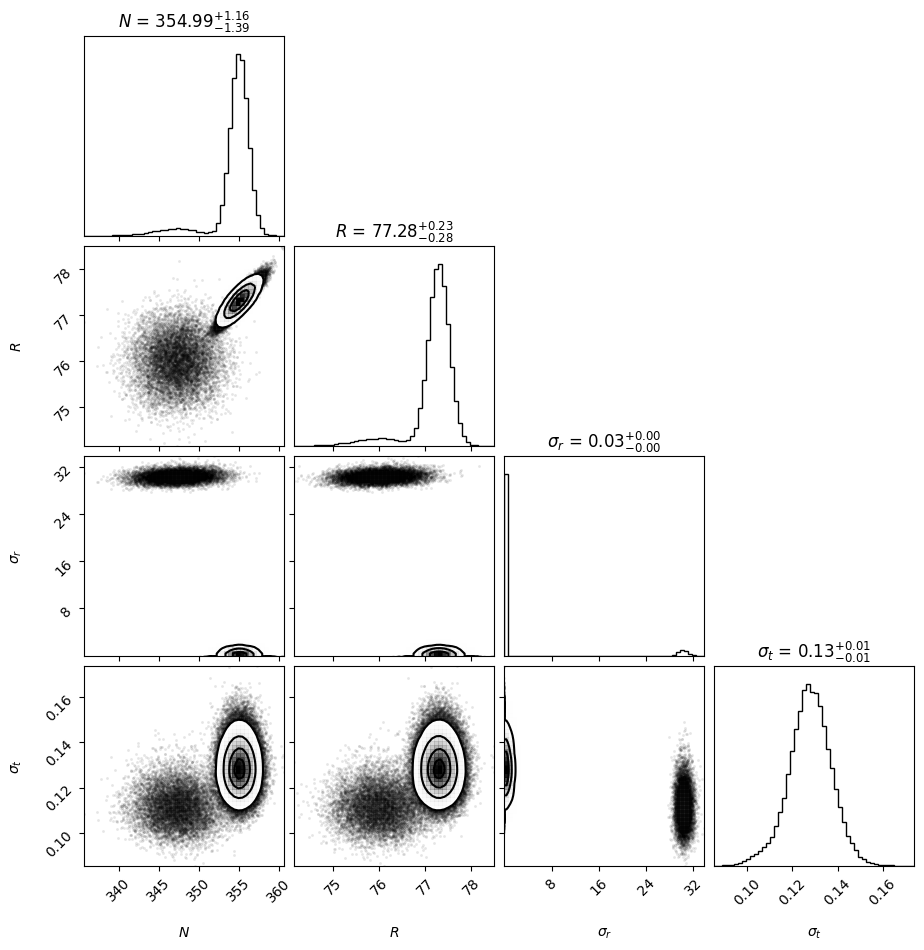

In [30]:
import matplotlib.pyplot as plt
import corner

# Extract samples
samples = mcmc.get_samples()
posterior_samples = jnp.vstack((
    samples['N'],
    samples['R'],
    samples['sigma_r'],
    samples['sigma_t']
)).T

posterior_samples_np = np.array(posterior_samples)

# Generate Corner Plot
fig = corner.corner(
    posterior_samples_np,
    labels=[r'$N$', r'$R$', r'$\sigma_r$', r'$\sigma_t$'],
    show_titles=True,
    bins=50,
    smooth=1.0
)
plt.show()


In [36]:
import jax.numpy as jnp

def log_likelihood_jax(params, data, use_anisotropic):
    """
    Computes the log-likelihood for the Antikythera Mechanism hole placement model using JAX.
    
    Implements a 2D Gaussian likelihood:
      - If `use_anisotropic` is True, uses different errors in radial (σ_r) and tangential (σ_t).
      - Otherwise, uses an isotropic Gaussian (σ) with equal error in x and y.

    Parameters:
    - params: Model parameters [N, R, sigma_r, sigma_t (or sigma), phases, xcents, ycents]
    - data: List of section-wise hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to switch between isotropic and anisotropic likelihoods.

    Returns:
    - Log-likelihood value.
    """
    # Extract primary parameters
    N, R = params[:2]
    
    if use_anisotropic:
        sigma_r, sigma_t = params[2:4]
    else:
        sigma_iso = params[2]
        sigma_r, sigma_t = sigma_iso, sigma_iso  # Isotropic case

    params_remaining = jnp.asarray(params[4:])
    assert len(params_remaining) % 3 == 0, f"Expected params[4:] length to be multiple of 3, got {len(params_remaining)}"
    phases, xcents, ycents = jnp.split(params_remaining, 3)

    logL = 0  # Log-likelihood accumulator

    # Iterate over each section of the ring
    for j, sect in enumerate(data):
        x, y = sect
        num_holes = len(x)

        # Correct Angular Positions
        phi = (2 * jnp.pi * (jnp.arange(1, num_holes + 1) - 1) / N) + phases[j]

        # Compute expected model positions
        x_model = R * jnp.cos(phi) + xcents[j]
        y_model = R * jnp.sin(phi) + ycents[j]

        # Compute error vectors in cartesian coordinates
        error_x = x - x_model
        error_y = y - y_model

        ### --- Isotropic Model --- ###
        if not use_anisotropic:
            sigma_val = sigma_r  # In isotropic case, sigma_r == sigma_t == sigma_val
            log_likelihoods_variable = (-0.5 * (error_x**2 + error_y**2) / sigma_val**2)
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_val**2)

        ### --- Anisotropic Model --- ###
        else:
            # Translate error vectors to radial and tangential coordinates
            unit_r = jnp.stack([jnp.cos(phi), jnp.sin(phi)], axis=1)
            unit_t = jnp.stack([jnp.sin(phi), -jnp.cos(phi)], axis=1)

            # List of radial and tangential error values for each hole
            error_r = error_x * unit_r[:, 0] + error_y * unit_r[:, 1]
            error_t = error_x * unit_t[:, 0] + error_y * unit_t[:, 1]

            # Compute anisotropic Gaussian likelihood for each hole
            log_likelihoods_variable = (-0.5 * ((error_r**2 / sigma_r**2) + (error_t**2 / sigma_t**2)))
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_r * sigma_t)

        # Accumulate log-likelihood
        logL += jnp.sum(log_likelihoods_variable) - log_likelihoods_constant

    return logL


In [38]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median
import jax

def bayesian_hole_position_model(data, use_anisotropic=True):
    """
    Bayesian model for hole positions using NumPyro.
    
    Parameters:
    - data: List of measured hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to enable anisotropic covariance matrix.
    """

    # 🔹 **Universal Priors (Ring-level parameters)**
    N = numpyro.sample('N', dist.Normal(355, 3))  # Centered at 355, with std=3
    R = numpyro.sample('R', dist.Normal(77.3, 0.5))  # Centered at 77.3, std=0.5

    if use_anisotropic:
        sigma_r = numpyro.sample('sigma_r', dist.LogNormal(jnp.log(0.028), 0.1))  # Constrains to positive values
        sigma_t = numpyro.sample('sigma_t', dist.LogNormal(jnp.log(0.129), 0.1))
    else:
        sigma_iso = numpyro.sample('sigma', dist.LogNormal(jnp.log(0.05), 0.1))

    # 🔹 **Section-Specific Priors**
    num_sections = len(data)  # Number of fractured sections in the dataset
    phases_median_degrees = jnp.array([-145.72, -145.67, -145.54, -146.71, -146.36, -147.80])
    phases_std_degrees = jnp.array([0.06, 0.19, 0.20, 0.90, 1.92, 0.42])
    phases = numpyro.sample('phases', dist.Normal(jnp.radians(phases_median_degrees), jnp.radians(phases_std_degrees)))  # Rotation offsets in radians
    x_offsets = numpyro.sample('x_offsets', dist.Normal(80, 3).expand([num_sections]))  # X-offset per section
    y_offsets = numpyro.sample('y_offsets', dist.Normal(135, 3).expand([num_sections]))  # Y-offset per section

    # 🔹 **Likelihood Calculation**
    params = jnp.concatenate([
        jnp.array([N, R, sigma_r, sigma_t] if use_anisotropic else [N, R, sigma_iso]),
        phases, x_offsets, y_offsets
    ])

    logL = log_likelihood_jax(params=params, data=data, use_anisotropic=use_anisotropic)

    # 🔹 **Define Log-Likelihood in NumPyro**
    numpyro.factor("log_likelihood", logL)

# Load and preprocess the data
file_path = "dataverse_files/1-Fragment_C_Hole_Measurements.csv"
df = pd.read_csv(file_path)
df = df.sort_values(by=["Section ID", "Hole"])  # Sort by section and hole index

# Remove Sections 0 and 4
valid_sections = [1, 2, 3, 5, 6, 7]  # Keep only these sections
df_filtered = df[df["Section ID"].isin(valid_sections)]

# Group by Section ID
data_list = []
grouped = df_filtered.groupby("Section ID")

for section_id, group in grouped:
    x_values = group["Mean(X)"].values
    y_values = group["Mean(Y)"].values
    data_list.append((x_values, y_values))  # Append (x, y) tuple for this section

# Sanity Check
total_holes = sum(len(sect[0]) for sect in data_list)
assert total_holes == 79, f"Expected 79 holes, but got {total_holes}"

print("Data formatted correctly with 6 sections and 79 holes.")

# Run MCMC
num_chains = 12  # Use all 12 CPU cores
num_warmup = 8000  # Increase burn-in steps
num_samples = 10000  # Total samples per chain

nuts_kernel = NUTS(bayesian_hole_position_model, init_strategy=init_to_median)

mcmc = MCMC(nuts_kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

key = jax.random.PRNGKey(0)
mcmc.run(key, data_list, use_anisotropic=True)

# Print summary of MCMC results
mcmc.print_summary()

Data formatted correctly with 6 sections and 79 holes.


  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

...

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]

  0%|          | 0/18000 [00:00<?, ?it/s]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
           N    340.89      2.80    340.88    336.34    345.53  54401.43      1.00
           R     70.54      0.38     70.53     69.91     71.15  30105.06      1.00
   phases[0]     -2.54      0.00     -2.54     -2.55     -2.54 249197.85      1.00
   phases[1]     -2.54      0.00     -2.54     -2.55     -2.54 145695.55      1.00
   phases[2]     -2.53      0.00     -2.53     -2.53     -2.52 128463.02      1.00
   phases[3]     -2.47      0.01     -2.47     -2.50     -2.45  94398.87      1.00
   phases[4]     -2.27      0.03     -2.27     -2.31     -2.23  89679.05      1.00
   phases[5]     -2.55      0.01     -2.55     -2.57     -2.54  89304.84      1.00
     sigma_r      0.05      0.00      0.05      0.05      0.06  66957.23      1.00
     sigma_t     14.09      0.44     14.08     13.37     14.81 108665.96      1.00
x_offsets[0]     74.90      0.28     74.89     74.45     75.36  31560.28      1.00
x_o

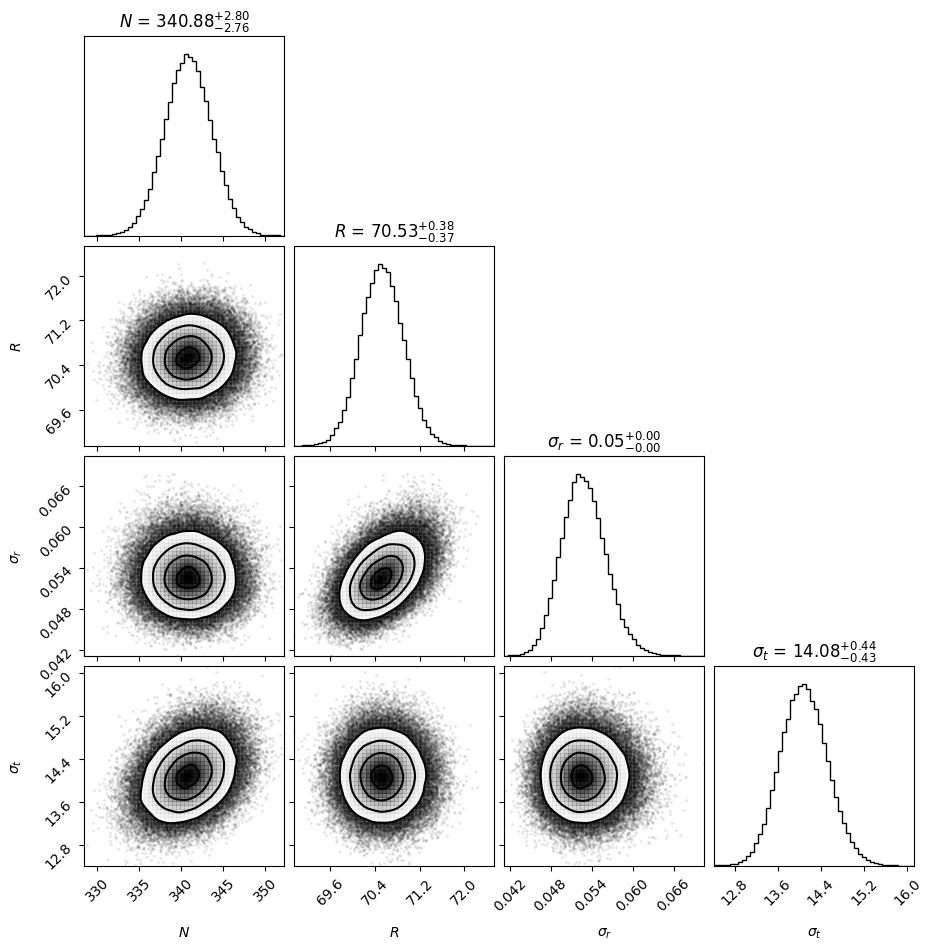

In [39]:
import matplotlib.pyplot as plt
import corner

# Extract samples
samples = mcmc.get_samples()
posterior_samples = jnp.vstack((
    samples['N'],
    samples['R'],
    samples['sigma_r'],
    samples['sigma_t']
)).T

posterior_samples_np = np.array(posterior_samples)

# Generate Corner Plot
fig = corner.corner(
    posterior_samples_np,
    labels=[r'$N$', r'$R$', r'$\sigma_r$', r'$\sigma_t$'],
    show_titles=True,
    bins=50,
    smooth=1.0
)
plt.show()


In [34]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median
import jax

def log_likelihood_jax(params, data, use_anisotropic):
    """
    Computes the log-likelihood for the Antikythera Mechanism hole placement model using JAX.
    
    Implements a 2D Gaussian likelihood:
      - If `use_anisotropic` is True, uses different errors in radial (σ_r) and tangential (σ_t).
      - Otherwise, uses an isotropic Gaussian (σ) with equal error in x and y.

    Parameters:
    - params: Model parameters [N, R, sigma_r, sigma_t (or sigma), phases, xcents, ycents]
    - data: List of section-wise hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to switch between isotropic and anisotropic likelihoods.

    Returns:
    - Log-likelihood value.
    """
    # Extract primary parameters
    N, R = params[:2]
    
    if use_anisotropic:
        sigma_r, sigma_t = params[2:4]
    else:
        sigma_iso = params[2]
        sigma_r, sigma_t = sigma_iso, sigma_iso  # Isotropic case

    params_remaining = jnp.asarray(params[4:])
    assert len(params_remaining) % 3 == 0, f"Expected params[4:] length to be multiple of 3, got {len(params_remaining)}"
    phases, xcents, ycents = jnp.split(params_remaining, 3)

    logL = 0  # Log-likelihood accumulator

    # Iterate over each section of the ring
    for j, sect in enumerate(data):
        x, y = sect
        num_holes = len(x)

        # Correct Angular Positions
        phi = (2 * jnp.pi * (jnp.arange(1, num_holes + 1) - 1) / N) + phases[j]

        # Compute expected model positions
        x_model = R * jnp.cos(phi) + xcents[j]
        y_model = R * jnp.sin(phi) + ycents[j]

        # Compute error vectors in cartesian coordinates
        error_x = x - x_model
        error_y = y - y_model

        ### --- Isotropic Model --- ###
        if not use_anisotropic:
            sigma_val = sigma_r  # In isotropic case, sigma_r == sigma_t == sigma_val
            log_likelihoods_variable = (-0.5 * (error_x**2 + error_y**2) / sigma_val**2)
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_val**2)

        ### --- Anisotropic Model --- ###
        else:
            # Translate error vectors to radial and tangential coordinates
            unit_r = jnp.stack([jnp.cos(phi), jnp.sin(phi)], axis=1)
            unit_t = jnp.stack([jnp.sin(phi), -jnp.cos(phi)], axis=1)

            # List of radial and tangential error values for each hole
            error_r = error_x * unit_r[:, 0] + error_y * unit_r[:, 1]
            error_t = error_x * unit_t[:, 0] + error_y * unit_t[:, 1]

            # Compute anisotropic Gaussian likelihood for each hole
            log_likelihoods_variable = (-0.5 * ((error_r**2 / sigma_r**2) + (error_t**2 / sigma_t**2)))
            log_likelihoods_constant = num_holes * jnp.log(2 * jnp.pi * sigma_r * sigma_t)

        # Accumulate log-likelihood
        logL += jnp.sum(log_likelihoods_variable) - log_likelihoods_constant

    return logL

def bayesian_hole_position_model(data, use_anisotropic=True):
    """
    Bayesian model for hole positions using NumPyro.
    
    Parameters:
    - data: List of measured hole position data [(x1, y1), (x2, y2), ..., (xs, ys)]
    - use_anisotropic: Boolean flag to enable anisotropic covariance matrix.
    """

    # 🔹 **Universal Priors (Ring-level parameters)**
    N = numpyro.sample('N', dist.Normal(355, 3))  # Centered at 355, with std=3
    R = numpyro.sample('R', dist.Normal(77.3, 0.5))  # Centered at 77.3, std=0.5

    if use_anisotropic:
        sigma_r = numpyro.sample('sigma_r', dist.LogNormal(jnp.log(0.028), 0.1))  # Constrains to positive values
        sigma_t = numpyro.sample('sigma_t', dist.LogNormal(jnp.log(0.129), 0.1))
    else:
        sigma_iso = numpyro.sample('sigma', dist.LogNormal(jnp.log(0.05), 0.1))

    # 🔹 **Section-Specific Priors**
    num_sections = len(data)  # Number of fractured sections in the dataset
    phases = numpyro.sample('phases', dist.Normal(-2.53073, 0.1).expand([num_sections]))  # Rotation offsets in radians
    x_offsets = numpyro.sample('x_offsets', dist.Normal(80, 3).expand([num_sections]))  # X-offset per section
    y_offsets = numpyro.sample('y_offsets', dist.Normal(135, 3).expand([num_sections]))  # Y-offset per section

    # 🔹 **Likelihood Calculation**
    params = jnp.concatenate([
        jnp.array([N, R, sigma_r, sigma_t] if use_anisotropic else [N, R, sigma_iso]),
        phases, x_offsets, y_offsets
    ])

    logL = log_likelihood_jax(params=params, data=data, use_anisotropic=use_anisotropic)

    # 🔹 **Define Log-Likelihood in NumPyro**
    numpyro.factor("log_likelihood", logL)

# Load and preprocess the data
file_path = "dataverse_files/1-Fragment_C_Hole_Measurements.csv"
df = pd.read_csv(file_path)
df = df.sort_values(by=["Section ID", "Hole"])  # Sort by section and hole index

# Remove Sections 0 and 4
valid_sections = [1, 2, 3, 5, 6, 7]  # Keep only these sections
df_filtered = df[df["Section ID"].isin(valid_sections)]

# Group by Section ID
data_list = []
grouped = df_filtered.groupby("Section ID")

for section_id, group in grouped:
    x_values = group["Mean(X)"].values
    y_values = group["Mean(Y)"].values
    data_list.append((x_values, y_values))  # Append (x, y) tuple for this section

# Sanity Check
total_holes = sum(len(sect[0]) for sect in data_list)
assert total_holes == 79, f"Expected 79 holes, but got {total_holes}"

print("Data formatted correctly with 6 sections and 79 holes.")

# Run MCMC
num_chains = 12  # Use all 12 CPU cores
num_warmup = 10000  # Increase burn-in steps
num_samples = 15000  # Increase total samples per chain

nuts_kernel = NUTS(bayesian_hole_position_model, init_strategy=init_to_median)

mcmc = MCMC(nuts_kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

key = jax.random.PRNGKey(0)
mcmc.run(key, data_list, use_anisotropic=True)

# Print summary of MCMC results
mcmc.print_summary()

Data formatted correctly with 6 sections and 79 holes.


  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

...

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 0/25000 [00:00<?, ?it/s]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
           N    354.99      1.13    354.99    353.13    356.83  50671.25      1.00
           R     77.29      0.23     77.29     76.91     77.66  46412.01      1.00
   phases[0]     -2.53      0.00     -2.53     -2.53     -2.52  99575.63      1.00
   phases[1]     -2.14      0.00     -2.14     -2.14     -2.13 149215.84      1.00
   phases[2]     -1.97      0.00     -1.97     -1.98     -1.97  58552.03      1.00
   phases[3]     -1.34      0.01     -1.34     -1.37     -1.32 116878.37      1.00
   phases[4]     -1.33      0.03     -1.33     -1.37     -1.29 110338.55      1.00
   phases[5]     -1.26      0.01     -1.26     -1.26     -1.25 131648.59      1.00
     sigma_r      0.03      0.00      0.03      0.03      0.03 171685.88      1.00
     sigma_t      0.13      0.01      0.13      0.12      0.14 201229.05      1.00
x_offsets[0]     79.65      0.16     79.65     79.39     79.93  49269.77      1.00
x_o

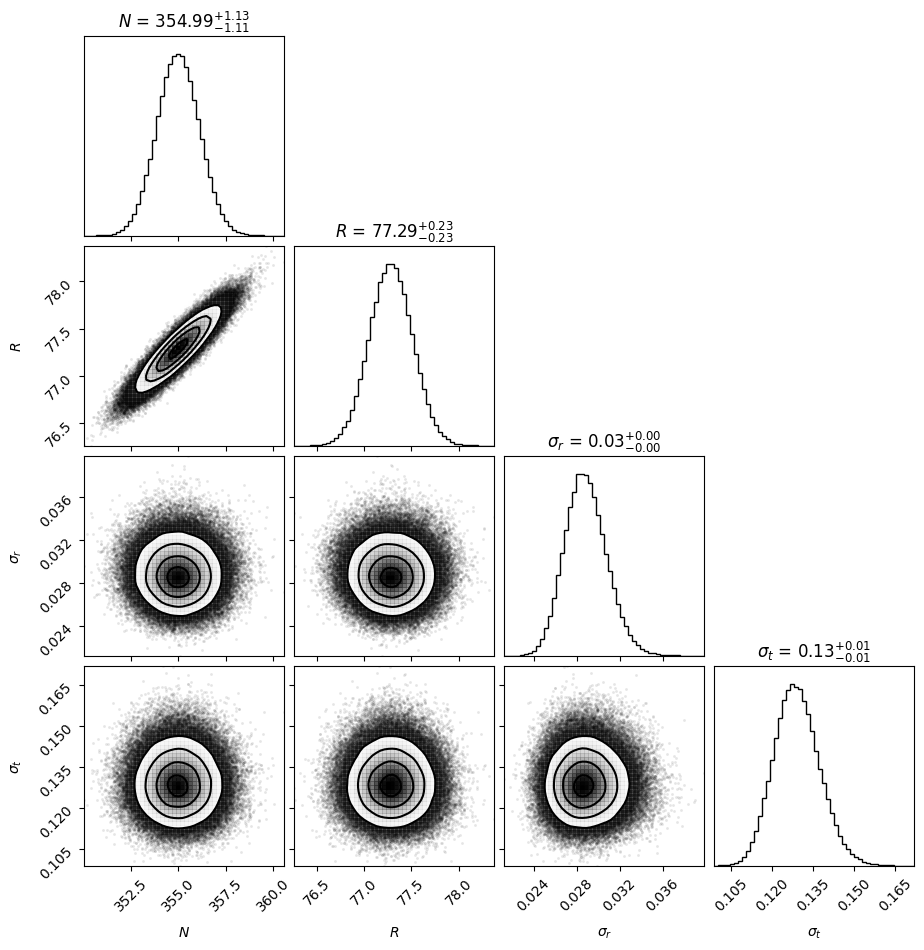

In [35]:
import matplotlib.pyplot as plt
import corner

# Extract samples
samples = mcmc.get_samples()
posterior_samples = jnp.vstack((
    samples['N'],
    samples['R'],
    samples['sigma_r'],
    samples['sigma_t']
)).T

posterior_samples_np = np.array(posterior_samples)

# Generate Corner Plot
fig = corner.corner(
    posterior_samples_np,
    labels=[r'$N$', r'$R$', r'$\sigma_r$', r'$\sigma_t$'],
    show_titles=True,
    bins=50,
    smooth=1.0
)
plt.show()
